# 02 — Exploratory Data Analysis (EDA)

**Objective**: Discover patterns, distributions, and relationships in the cleaned Indian colleges dataset through comprehensive visual analysis.

**Dataset**: `datasets/processed/colleges_cleaned.csv` — 211 colleges, 32 features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

df = pd.read_csv('../datasets/processed/colleges_cleaned.csv')
print(f'Dataset: {df.shape[0]} colleges, {df.shape[1]} features')

Dataset: 211 colleges, 32 features


## 1. Univariate Analysis — Categorical Variables

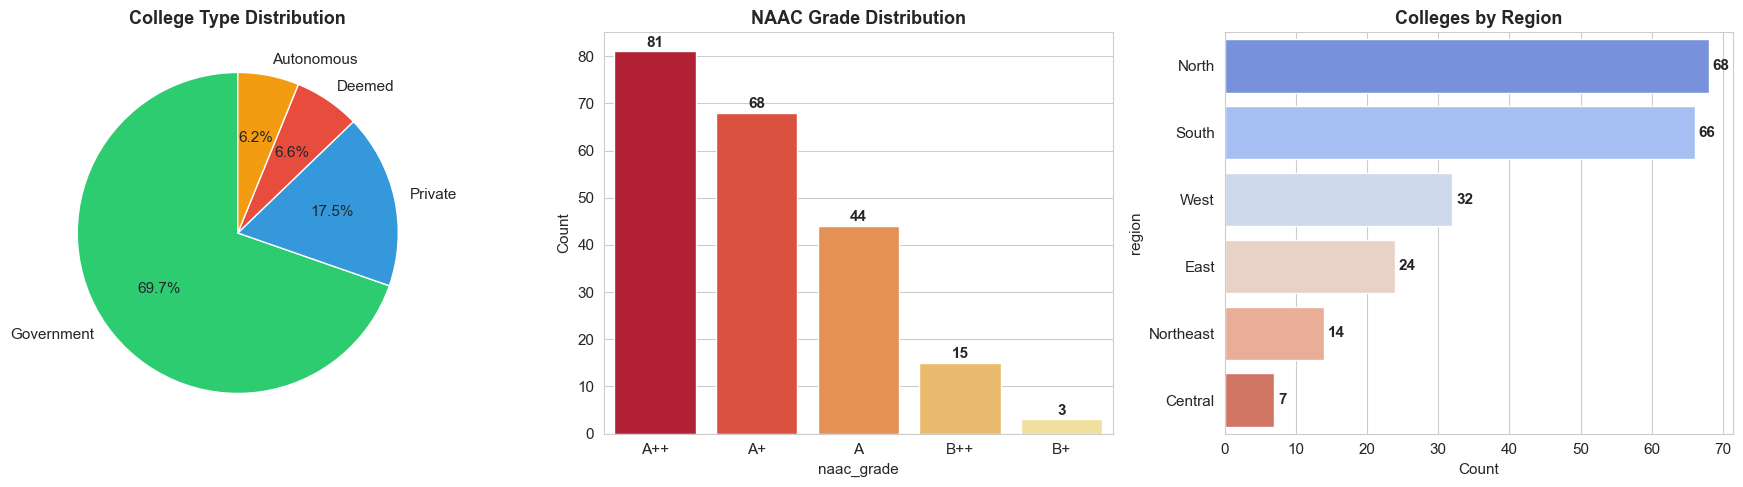

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# College Type Distribution
type_counts = df['type'].value_counts()
colors_type = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=colors_type, startangle=90)
axes[0].set_title('College Type Distribution', fontweight='bold', fontsize=13)

# NAAC Grade Distribution
naac_order = ['A++', 'A+', 'A', 'B++', 'B+', 'B']
naac_counts = df['naac_grade'].value_counts().reindex(naac_order).dropna()
sns.barplot(x=naac_counts.index, y=naac_counts.values, ax=axes[1], palette='YlOrRd_r')
axes[1].set_title('NAAC Grade Distribution', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Count')
for i, v in enumerate(naac_counts.values):
    axes[1].text(i, v + 1, str(int(v)), ha='center', fontweight='bold')

# Region Distribution
region_counts = df['region'].value_counts()
sns.barplot(x=region_counts.values, y=region_counts.index, ax=axes[2], palette='coolwarm')
axes[2].set_title('Colleges by Region', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Count')
for i, v in enumerate(region_counts.values):
    axes[2].text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/visualizations/eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

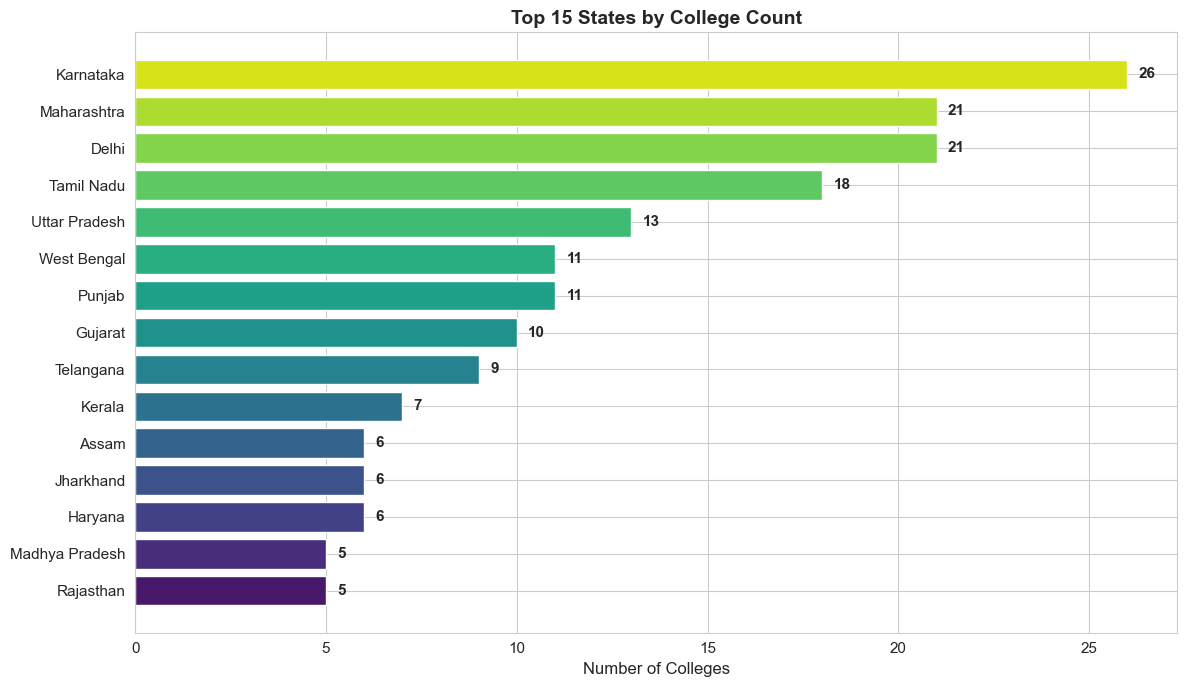

In [3]:
# Top 15 states by college count
fig, ax = plt.subplots(figsize=(12, 7))
state_counts = df['state'].value_counts().head(15)
bars = ax.barh(state_counts.index[::-1], state_counts.values[::-1], color=sns.color_palette('viridis', 15))
ax.set_xlabel('Number of Colleges', fontsize=12)
ax.set_title('Top 15 States by College Count', fontweight='bold', fontsize=14)
for bar, val in zip(bars, state_counts.values[::-1]):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/visualizations/eda_states.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Univariate Analysis — Numeric Variables

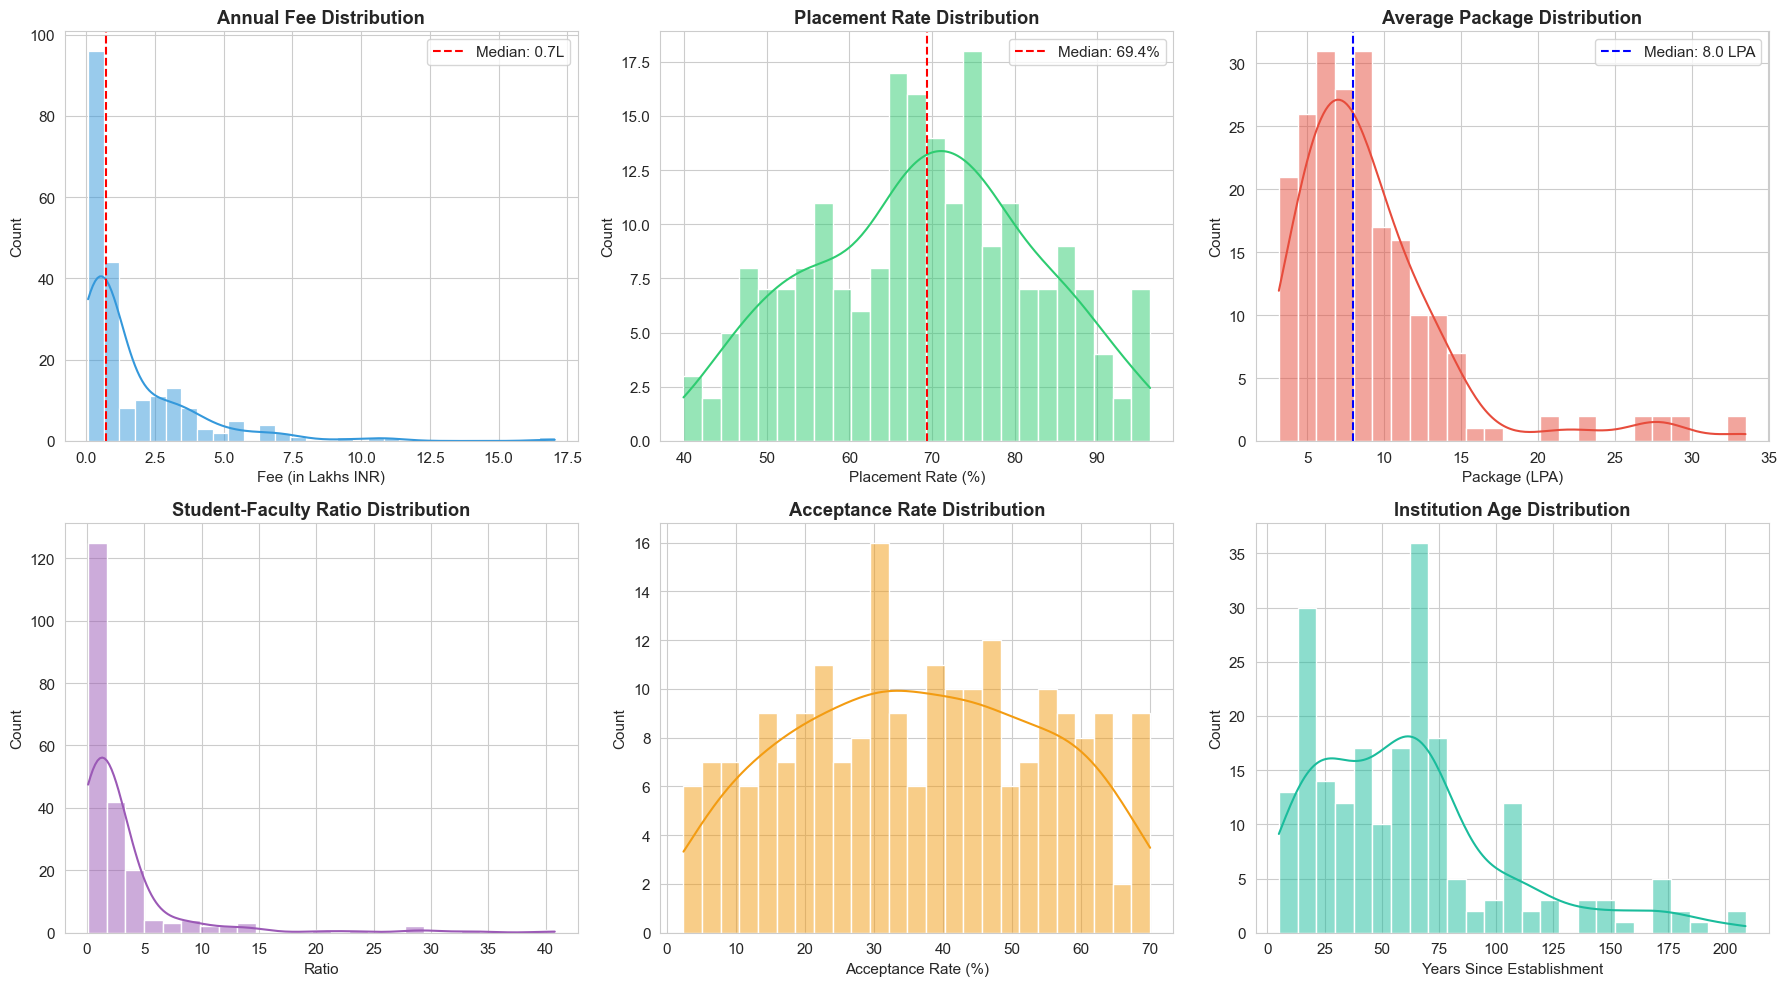

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Annual Fee Distribution
sns.histplot(df['avg_annual_fee']/100000, bins=30, kde=True, ax=axes[0,0], color='#3498db')
axes[0,0].set_title('Annual Fee Distribution', fontweight='bold')
axes[0,0].set_xlabel('Fee (in Lakhs INR)')
axes[0,0].axvline(df['avg_annual_fee'].median()/100000, color='red', linestyle='--', label=f'Median: {df["avg_annual_fee"].median()/100000:.1f}L')
axes[0,0].legend()

# Placement Rate Distribution
sns.histplot(df['placement_rate'], bins=25, kde=True, ax=axes[0,1], color='#2ecc71')
axes[0,1].set_title('Placement Rate Distribution', fontweight='bold')
axes[0,1].set_xlabel('Placement Rate (%)')
axes[0,1].axvline(df['placement_rate'].median(), color='red', linestyle='--', label=f'Median: {df["placement_rate"].median():.1f}%')
axes[0,1].legend()

# Average Package Distribution
sns.histplot(df['avg_package_lpa'], bins=25, kde=True, ax=axes[0,2], color='#e74c3c')
axes[0,2].set_title('Average Package Distribution', fontweight='bold')
axes[0,2].set_xlabel('Package (LPA)')
axes[0,2].axvline(df['avg_package_lpa'].median(), color='blue', linestyle='--', label=f'Median: {df["avg_package_lpa"].median():.1f} LPA')
axes[0,2].legend()

# Student Faculty Ratio
sns.histplot(df['student_faculty_ratio'], bins=25, kde=True, ax=axes[1,0], color='#9b59b6')
axes[1,0].set_title('Student-Faculty Ratio Distribution', fontweight='bold')
axes[1,0].set_xlabel('Ratio')

# Acceptance Rate
sns.histplot(df['acceptance_rate'], bins=25, kde=True, ax=axes[1,1], color='#f39c12')
axes[1,1].set_title('Acceptance Rate Distribution', fontweight='bold')
axes[1,1].set_xlabel('Acceptance Rate (%)')

# Institution Age
sns.histplot(df['institution_age'], bins=25, kde=True, ax=axes[1,2], color='#1abc9c')
axes[1,2].set_title('Institution Age Distribution', fontweight='bold')
axes[1,2].set_xlabel('Years Since Establishment')

plt.tight_layout()
plt.savefig('../outputs/visualizations/eda_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Bivariate Analysis

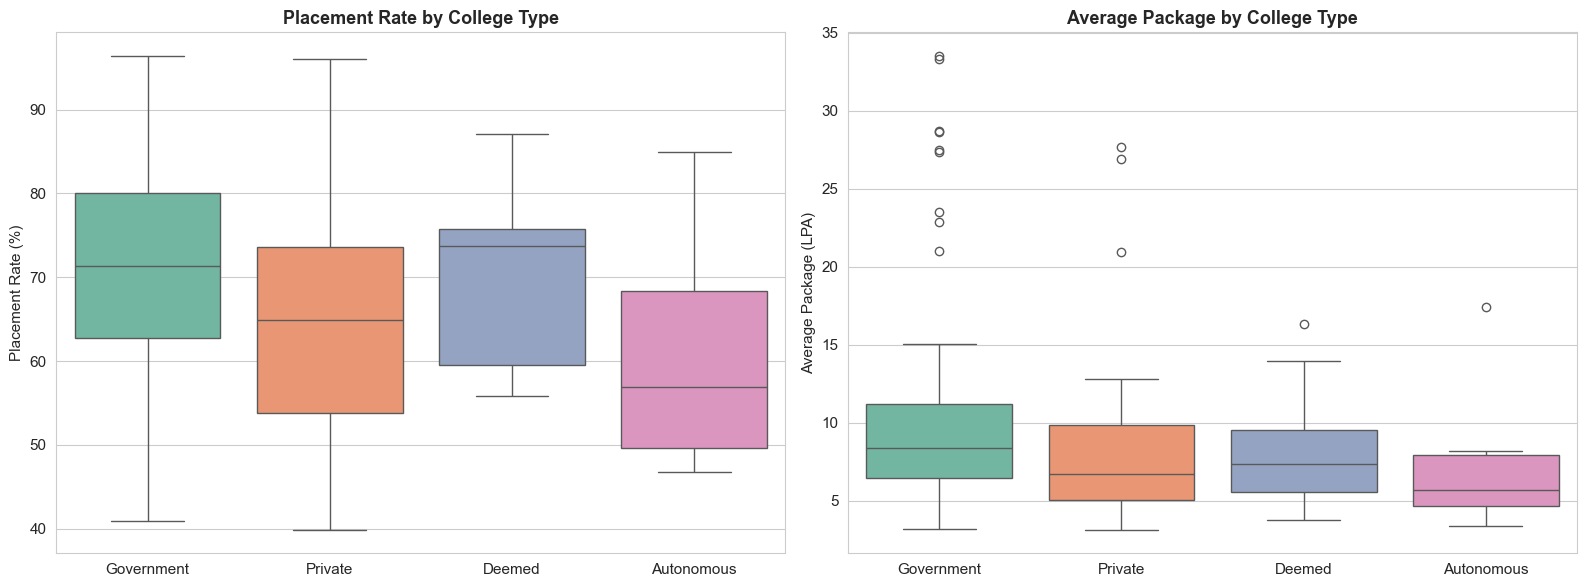

Key Finding: Government colleges show higher median placement rates and packages,
while private colleges show wider variance (some elite private institutes match top govt colleges).


In [5]:
# Placement Rate by College Type
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='type', y='placement_rate', ax=axes[0], palette='Set2')
axes[0].set_title('Placement Rate by College Type', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Placement Rate (%)')
axes[0].set_xlabel('')

# Average Package by College Type
sns.boxplot(data=df, x='type', y='avg_package_lpa', ax=axes[1], palette='Set2')
axes[1].set_title('Average Package by College Type', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Average Package (LPA)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../outputs/visualizations/eda_type_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Key insight
print('Key Finding: Government colleges show higher median placement rates and packages,')
print('while private colleges show wider variance (some elite private institutes match top govt colleges).')

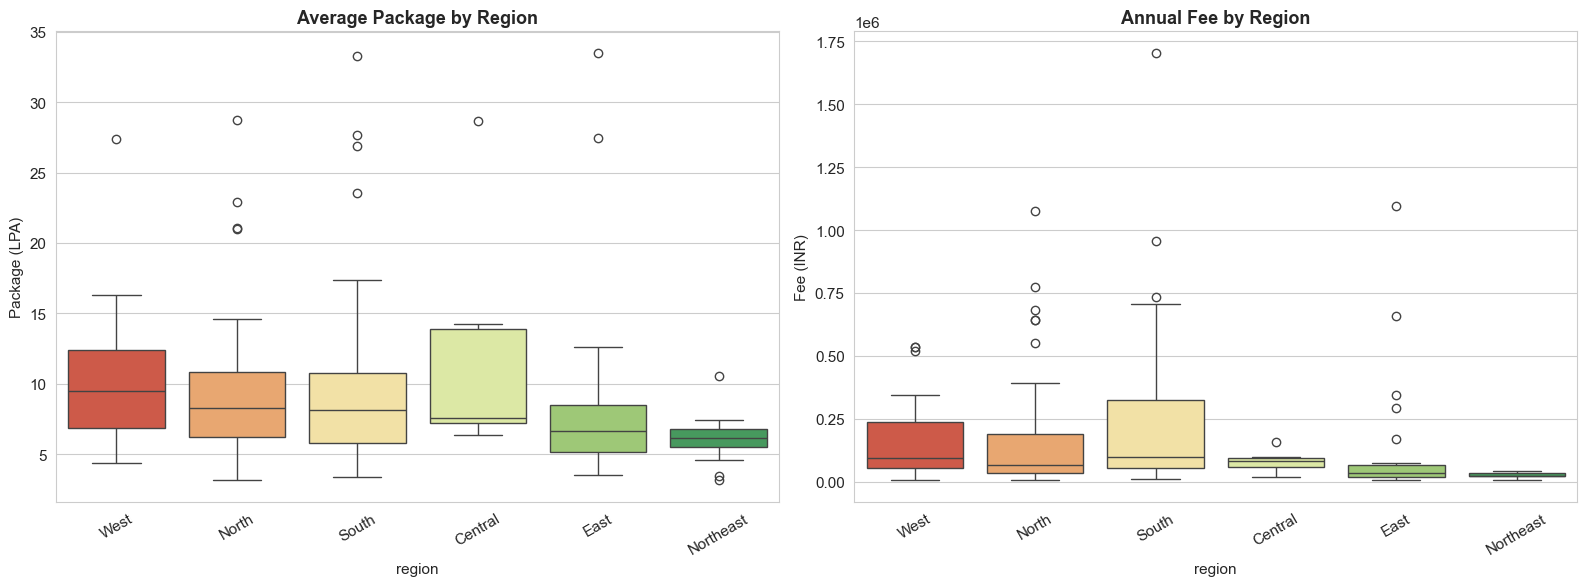

In [6]:
# Average Package by Region
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

region_order = df.groupby('region')['avg_package_lpa'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='region', y='avg_package_lpa', order=region_order, ax=axes[0], palette='RdYlGn')
axes[0].set_title('Average Package by Region', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Package (LPA)')
axes[0].tick_params(axis='x', rotation=30)

# Avg Fee by Region
sns.boxplot(data=df, x='region', y='avg_annual_fee', order=region_order, ax=axes[1], palette='RdYlGn')
axes[1].set_title('Annual Fee by Region', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Fee (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/visualizations/eda_region_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

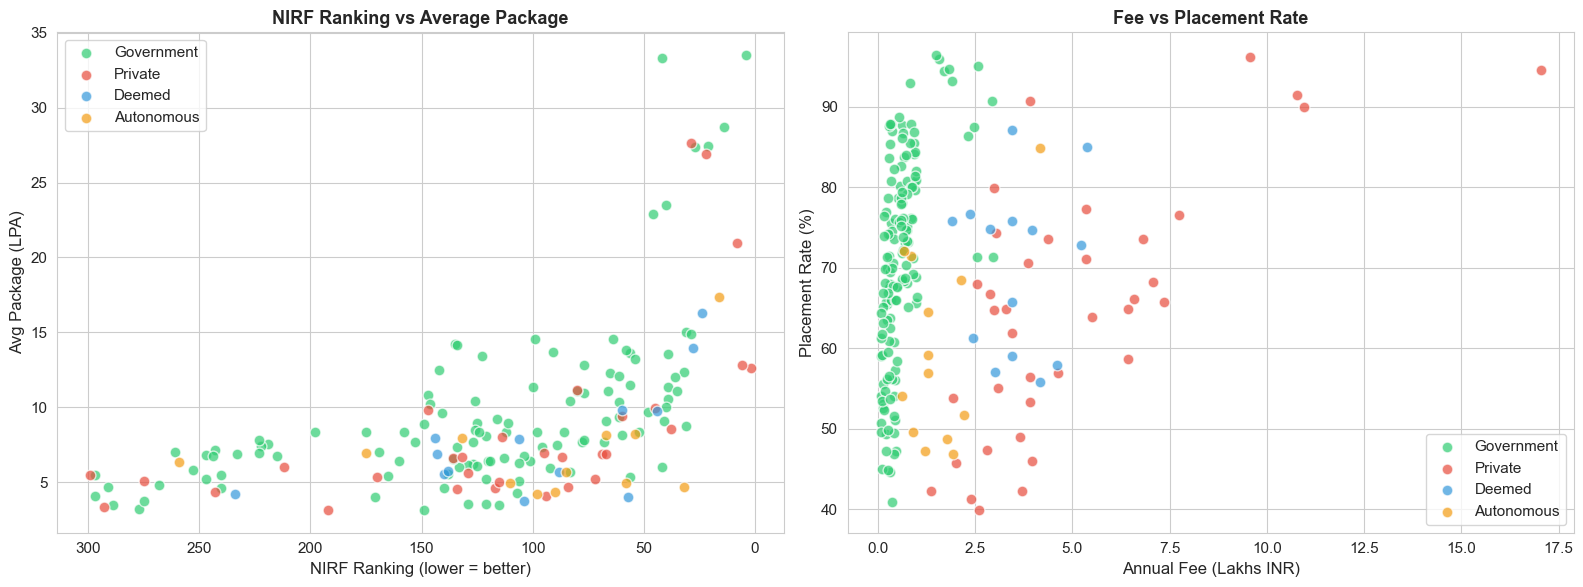

Key Finding: Top-ranked colleges (NIRF < 50) command significantly higher packages.
Government colleges achieve high placement rates at lower fees — best ROI.


In [7]:
# Scatter: NIRF Ranking vs Average Package
ranked = df.dropna(subset=['nirf_ranking'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for college_type, color in zip(['Government', 'Private', 'Deemed', 'Autonomous'], 
                                ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']):
    subset = ranked[ranked['type'] == college_type]
    axes[0].scatter(subset['nirf_ranking'], subset['avg_package_lpa'], 
                    label=college_type, alpha=0.7, s=60, color=color, edgecolors='white')

axes[0].set_xlabel('NIRF Ranking (lower = better)', fontsize=12)
axes[0].set_ylabel('Avg Package (LPA)', fontsize=12)
axes[0].set_title('NIRF Ranking vs Average Package', fontweight='bold', fontsize=13)
axes[0].legend()
axes[0].invert_xaxis()

# Scatter: Fees vs Placement Rate
for college_type, color in zip(['Government', 'Private', 'Deemed', 'Autonomous'], 
                                ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']):
    subset = df[df['type'] == college_type]
    axes[1].scatter(subset['avg_annual_fee']/100000, subset['placement_rate'], 
                    label=college_type, alpha=0.7, s=60, color=color, edgecolors='white')

axes[1].set_xlabel('Annual Fee (Lakhs INR)', fontsize=12)
axes[1].set_ylabel('Placement Rate (%)', fontsize=12)
axes[1].set_title('Fee vs Placement Rate', fontweight='bold', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/visualizations/eda_scatter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key Finding: Top-ranked colleges (NIRF < 50) command significantly higher packages.')
print('Government colleges achieve high placement rates at lower fees — best ROI.')

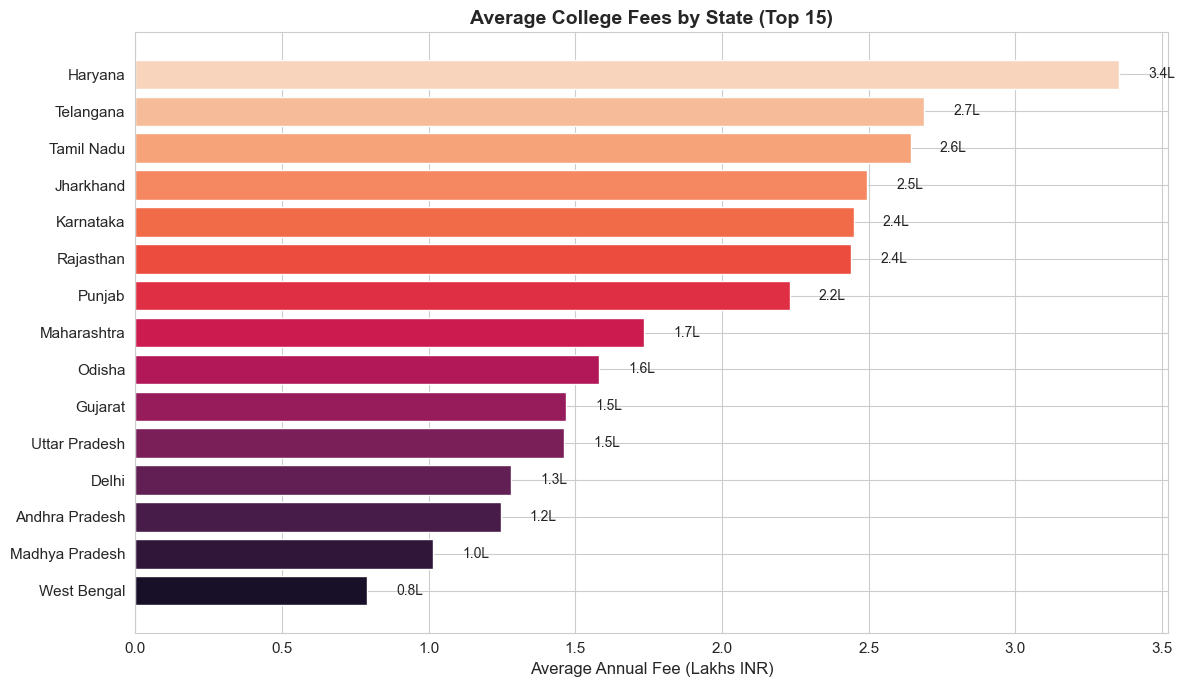

In [8]:
# Average fees by state (Top 15)
fig, ax = plt.subplots(figsize=(12, 7))
state_fees = df.groupby('state')['avg_annual_fee'].mean().sort_values(ascending=True).tail(15)
bars = ax.barh(state_fees.index, state_fees.values/100000, color=sns.color_palette('rocket', 15))
ax.set_xlabel('Average Annual Fee (Lakhs INR)', fontsize=12)
ax.set_title('Average College Fees by State (Top 15)', fontweight='bold', fontsize=14)
for bar, val in zip(bars, state_fees.values/100000):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}L', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/visualizations/eda_fees_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Multivariate Analysis

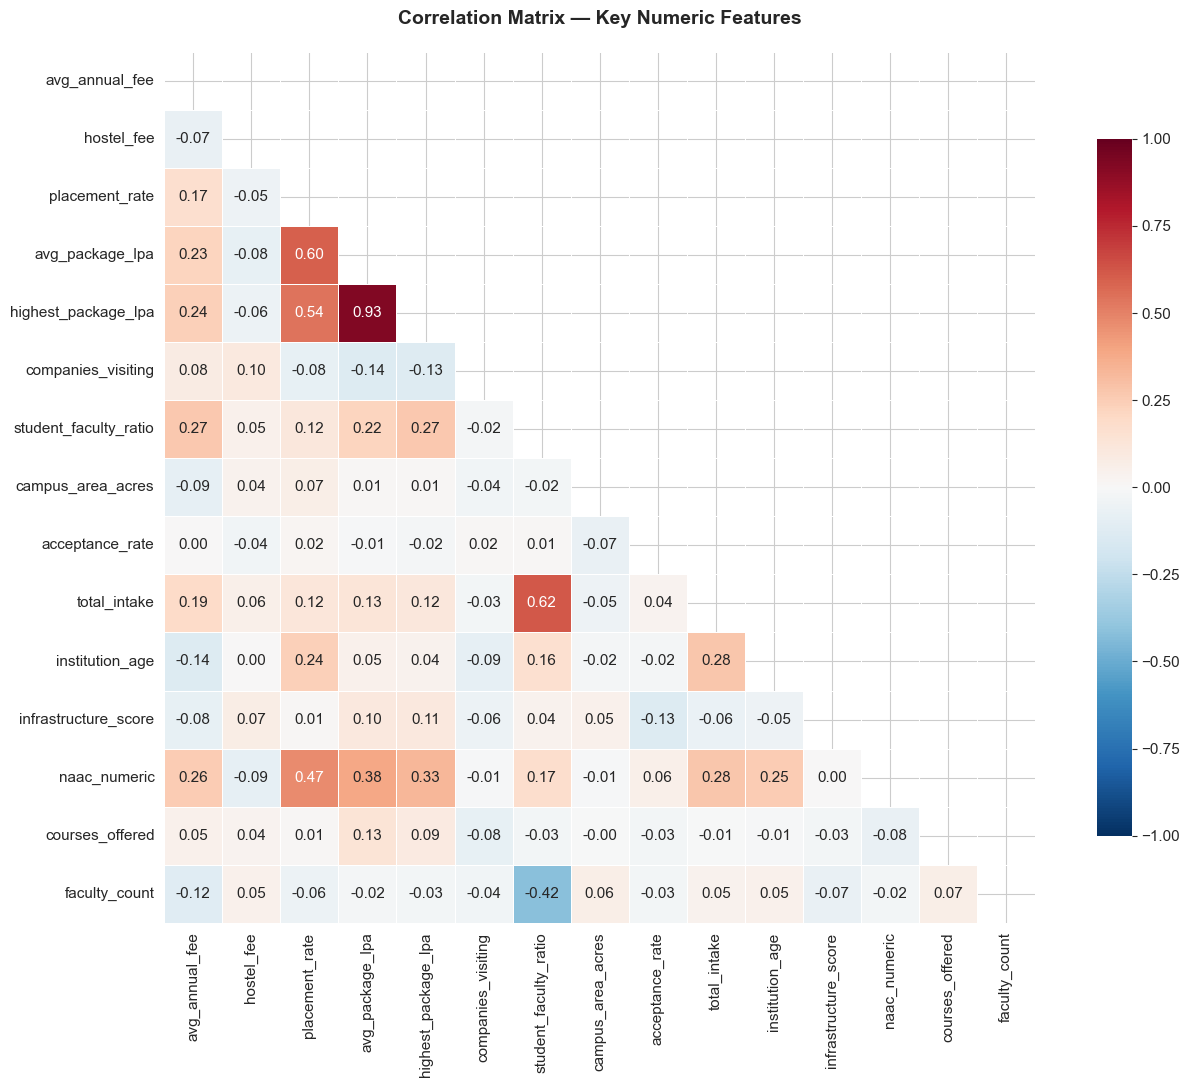


Top 10 Strongest Correlations:
  highest_package_lpa ↔ avg_package_lpa: 0.927
  total_intake ↔ student_faculty_ratio: 0.621
  placement_rate ↔ avg_package_lpa: 0.596
  highest_package_lpa ↔ placement_rate: 0.541
  placement_rate ↔ naac_numeric: 0.474
  avg_package_lpa ↔ naac_numeric: 0.385
  highest_package_lpa ↔ naac_numeric: 0.330
  total_intake ↔ naac_numeric: 0.278
  total_intake ↔ institution_age: 0.278
  student_faculty_ratio ↔ avg_annual_fee: 0.273


In [9]:
# Correlation Heatmap
numeric_cols = ['avg_annual_fee', 'hostel_fee', 'placement_rate', 'avg_package_lpa', 
                'highest_package_lpa', 'companies_visiting', 'student_faculty_ratio',
                'campus_area_acres', 'acceptance_rate', 'total_intake', 'institution_age',
                'infrastructure_score', 'naac_numeric', 'courses_offered', 'faculty_count']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Key Numeric Features', fontweight='bold', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../outputs/visualizations/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations
print('\nTop 10 Strongest Correlations:')
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]  # Remove self-correlations
seen = set()
count = 0
for (col1, col2), val in corr_pairs.items():
    pair = tuple(sorted([col1, col2]))
    if pair not in seen:
        seen.add(pair)
        print(f'  {col1} ↔ {col2}: {val:.3f}')
        count += 1
        if count >= 10:
            break

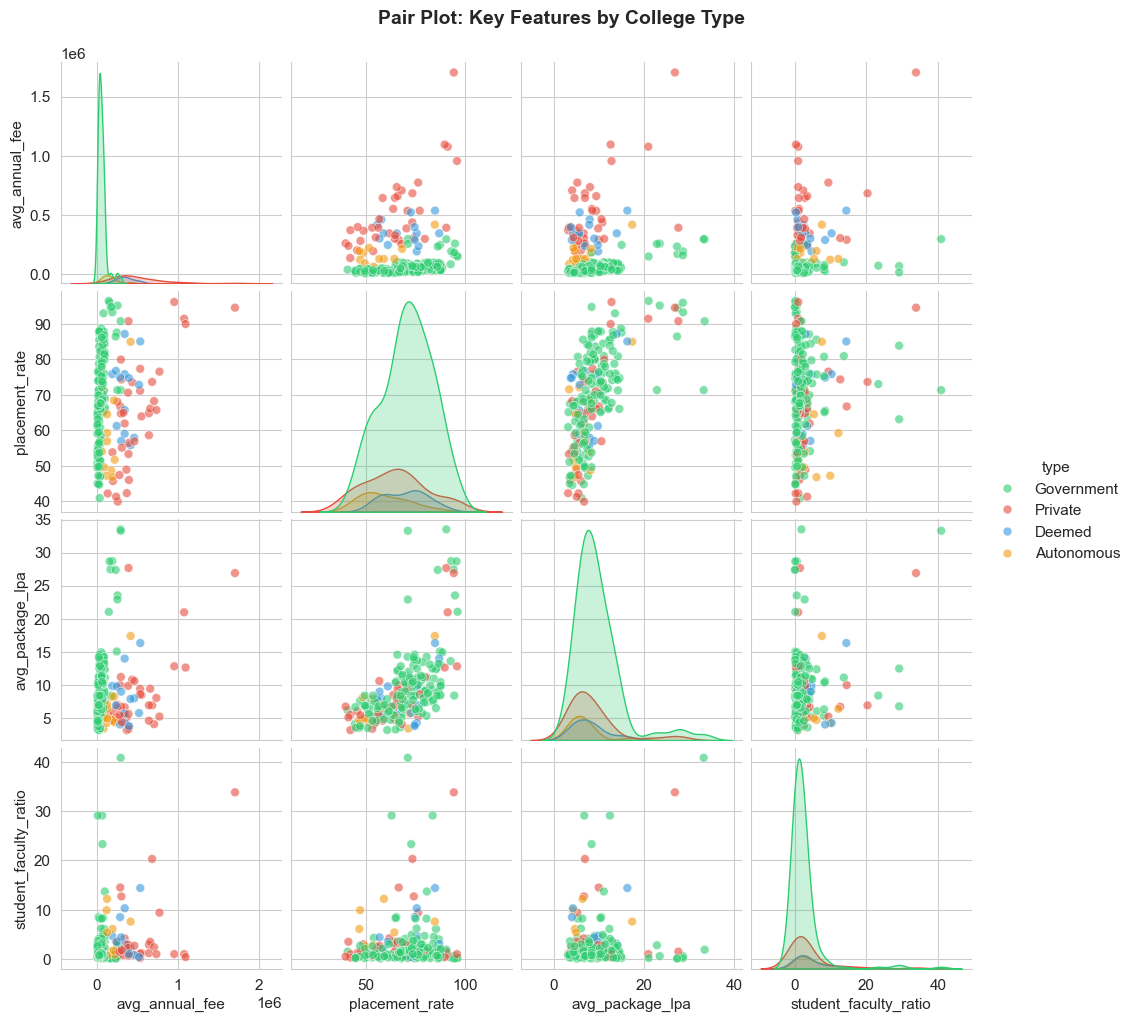

In [10]:
# Pair Plot for key features
key_features = ['avg_annual_fee', 'placement_rate', 'avg_package_lpa', 'student_faculty_ratio']
g = sns.pairplot(df[key_features + ['type']], hue='type', 
                 palette={'Government': '#2ecc71', 'Private': '#e74c3c', 'Deemed': '#3498db', 'Autonomous': '#f39c12'},
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 40})
g.figure.suptitle('Pair Plot: Key Features by College Type', fontweight='bold', y=1.02, fontsize=14)
plt.savefig('../outputs/visualizations/eda_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Geographic Analysis

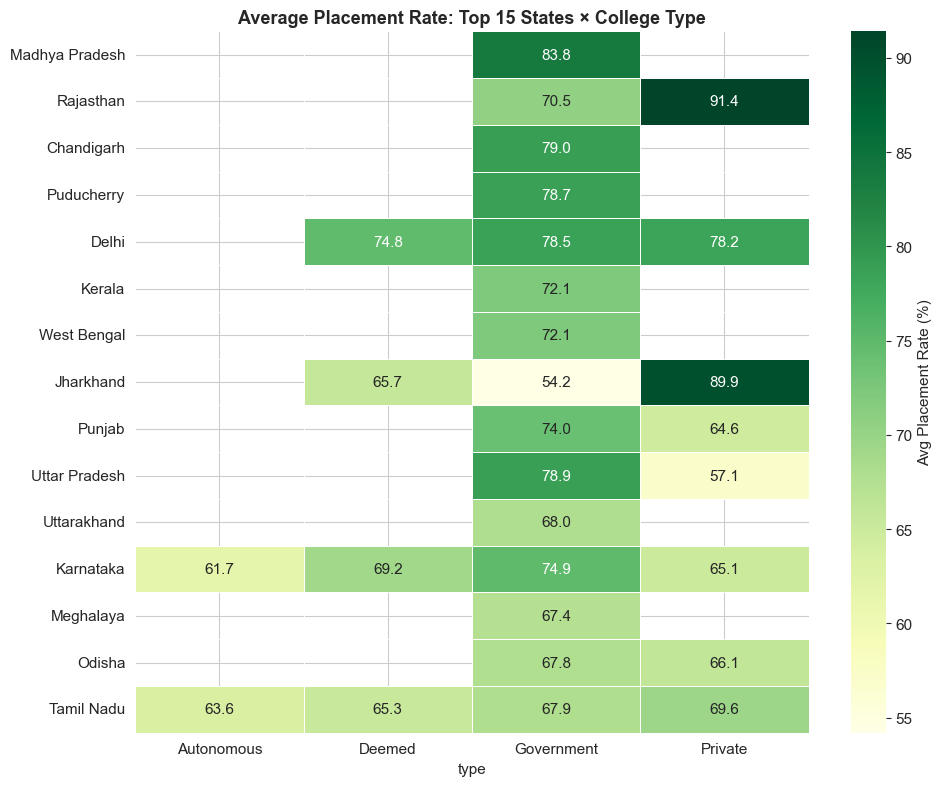

In [11]:
# Heatmap: Average placement rate by State and Type
pivot = df.pivot_table(values='placement_rate', index='state', columns='type', aggfunc='mean')
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).head(15).index]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Avg Placement Rate (%)'})
ax.set_title('Average Placement Rate: Top 15 States × College Type', fontweight='bold', fontsize=13)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../outputs/visualizations/eda_state_type_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Region-wise summary stats
region_summary = df.groupby('region').agg({
    'name': 'count',
    'avg_annual_fee': 'mean',
    'placement_rate': 'mean',
    'avg_package_lpa': 'mean',
    'acceptance_rate': 'mean'
}).round(2)
region_summary.columns = ['College Count', 'Avg Fee (INR)', 'Avg Placement %', 'Avg Package (LPA)', 'Avg Acceptance %']
region_summary = region_summary.sort_values('Avg Package (LPA)', ascending=False)
print('Region-wise Summary:')
region_summary

Region-wise Summary:


,College Count,Avg Fee (INR),Avg Placement %,Avg Package (LPA),Avg Acceptance %
region,,,,,
Central,7,81847.43,73.63,12.12,38.06
West,32,160939.56,71.97,10.06,43.72
South,66,219743.47,67.99,9.41,32.88
North,68,157805.23,71.46,9.00,38.12
East,24,132593.17,67.03,8.74,31.80
Northeast,14,27454.29,56.74,6.09,36.44


## 6. Key Findings Summary

### Distribution Insights
1. **Government dominance**: ~60% of top institutions are government-run
2. **South India leads**: Karnataka, Tamil Nadu, and Maharashtra have the highest concentration of quality institutions
3. **Fee disparity**: Private college fees (median ~5-8L) are 5-10x higher than government colleges (median ~0.5-1.5L)

### Relationship Insights
4. **Strong ROI at govt colleges**: Government colleges achieve comparable or better placement rates at significantly lower fees
5. **NIRF-Package correlation**: Top NIRF-ranked colleges (1-50) command 2-3x higher average packages
6. **avg_package and highest_package are highly correlated** (expected — colleges with good average placements also have strong top offers)

### Geographic Insights
7. **Regional inequality**: South and West India significantly outperform North and Northeast in placement outcomes
8. **Northeast gap**: Northeast India has the fewest colleges and lowest average packages — underserved region